In [16]:
import os
import numpy as np
import json
import glob
import random
import torch

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.figsize': [6,4]})

np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)

# from agents.control_agents_deep import build_fc_net

In [26]:
# some helper functions used by all experiments

def build_fc_net(layer_sizes, activation=torch.nn.Tanh(), final_activation_layer=torch.nn.Identity(), ortho_init=False):
    """Returns a full-connected network with an argument-specified activation function."""
    assert len(layer_sizes) > 1
    layers = []
    for index in range(len(layer_sizes) - 1):
        linear = torch.nn.Linear(layer_sizes[index], layer_sizes[index + 1])
        if ortho_init:
            torch.nn.init.orthogonal_(linear.weight, 1)
            torch.nn.init.constant_(linear.bias, 0)
        act = activation if index < len(layer_sizes) - 2 else final_activation_layer
        layers += (linear, act)
    return torch.nn.Sequential(*layers)

def all_files_with_prefix_and_suffix(location, prefix, suffix):
    """returns a list of all files in the 'location' starting with the given prefix"""
    if location[-1] != '/':
        location += '/'
    files = glob.glob(location + prefix + '*' + suffix)

    return files


def plot_sensitivity(param_list, item, param2='alpha', title=None, firstn=-1, last_from=-1, 
                     num_sa=None, logbase=-1, ylabel='RMSVE\n(TVR)', y_lims=None,
                     out_location=None, final=False, param_choose_only=None):

    data_all = {}
    X, Y = [], []
    for location, filename_prefix, param1 in param_list:
    
        files = all_files_with_prefix_and_suffix(location, filename_prefix, '*.npy')
        assert len(files) > 0, 'No files found with the prefix: ' + location + filename_prefix
        print('Filename\t%s\t%s\tValue\n' % (param1, param2))
        for file in files:
            data = np.load(file, allow_pickle=True).item()
            param1_value = data['params'][param1]
            if data['params'][param_choose_only[0]] != param_choose_only[1]:
                continue
            if data['params']['eta'] > 1:
                continue
            if param1_value not in data_all:
                data_all[param1_value] = {}
                X.append(param1_value)
            param2_value = data['params'][param2]
            if param2_value not in data_all[param1_value]:
                data_all[param1_value][param2_value] = {}
                Y.append(param2_value)
            assert not (firstn!=-1 and last_from!=-1), "Both firstn and lastn can't be chosen together"
            if firstn != -1:
                data_to_eval = data[item][:,:firstn]
            elif last_from != -1:
                data_to_eval = data[item][:,last_from:]
            else:
                data_to_eval = data[item]
            metric_per_run = np.mean(data_to_eval, axis=1)
            metric = np.mean(metric_per_run)
            metric_stderr = np.std(metric_per_run) / np.sqrt(metric_per_run.size)
            data_all[param1_value][param2_value] = (metric, metric_stderr)
            print('%s\t%s\t%s\t%.3f\t%.3f' % (file[-10:-3], param1_value, param2_value, metric, metric_stderr))

    try: 
        X = sorted(set(X))
    except:
        print('Cannot sort; keys are a mix of numbers and letters')
        X = data_all.keys()
    Y = sorted(set(Y))
    Z_mean = np.zeros((len(X), len(Y)))
    Z_stderr = np.zeros((len(X), len(Y)))
    Z_attrs = ['']*len(X)
    # print(Z_attrs)
    for i, x in enumerate(X):
        for j, y in enumerate(Y):
            try:
                Z_mean[i][j] = data_all[x][y][0]
                Z_stderr[i][j] = data_all[x][y][1]
            except:
                Z_mean[i][j] = np.nan
                Z_stderr[i][j] = np.nan
        print(i, x)
#         if x=='max_all_sa':
#             Z_attrs[i] = 'dashed'
    Z_mean = np.ma.masked_invalid(Z_mean)
    Z_stderr = np.ma.masked_invalid(Z_stderr)

    fig, ax = plt.subplots(1, 1)#, figsize=(5.5,4))

    # colors = ['darkturquoise', 'magenta']
    # if param_choose_only[0] in ['gamma', 'eta']:
    #     print('Changing value_init/reward_rate_init to reward_offset')
    #     X = list(map((lambda x: x * -1), X))
    for i, param_value in enumerate(X):
        ax.errorbar(Y, Z_mean[i], yerr=Z_stderr[i], label=str(param_value))#, linestyle=Z_attrs[i])#, color=colors[i])
    if final!=True:
        ax.legend()
        plt.xlabel(param2)
        plt.ylabel(ylabel, rotation=0, labelpad=40)
        ax.set_title(title)
    if y_lims != None:            # typically (0.21, 0.39) for TC, (2.05, 2.6) for AC, (0, 0.9) for Catcher
        plt.ylim(y_lims[0], y_lims[1])
    ax.grid(visible=True, axis='y', alpha=0.5, linestyle='--')
    if logbase != -1:
        ax.set_xscale("log", base=logbase)
    ax.set_xticks(Y)
    ax.set_xticklabels(Y)
    fig.tight_layout()
    if final==True:
        assert os.path.isfile(out_location + title + '.png') == False, "File already exists. Don't overwrite!"
        plt.savefig(out_location + title + '.png', dpi=1200, transparent=True)
    plt.show()


def plot_learning_curve(files, item='reward', window=1000, sample=1, firstn=-1,
                        title=None, h_line=None, ylims=None, plot_all_runs=False,
                        print_final_reward_rate=False, print_max_value_over_last_tenth=False,
                        out_location=None, final=False, file_title=None):

#     colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    colors = ['blue', 'orange', '#37f24a', '#2cbd3d', '#208c2b', '#f24235', '#bd332a', '#8f2822']
    fig, ax = plt.subplots(1, 1, figsize=(8,6))
    which_step_size = 'alpha_w'
    for i, (location, filename) in enumerate(files):
        data = np.load(location + filename, allow_pickle=True).item()
        rewards_train = data[item][:,:firstn]
#         if data['params']['robust_to_initialization']:
#             rewards_train -= data['params']['reward_offset']
        max_run_length = rewards_train.shape[1]
        if print_final_reward_rate:
            idx = int(data["avgrew"].shape[1] * 0.1)
#             print(f'Over {data["params"]["num_runs"]} runs: {np.mean(data["avgrew"][:,-10:])} +- {np.std(data["avgrew"][:,-10:])}')
            print(f'Learned reward rate (final): {np.mean(data["avgrew_final"]):.3f}')
            print(f'Learned reward rate over last 10%: {np.mean(data["avgrew"][:,-idx:]):.3f}')
        if print_max_value_over_last_tenth:
            print(f'Max value over the last 10% steps: {np.nanmean(data["max_value_per_step"])}\n')
        conv_arr = np.ones(window)
        reward_rate_all = []
        x_s = np.arange(window, max_run_length+1)[::sample] #* data['params']['eval_every_n_steps']
        # ToDo: vectorize this
        for run in range(rewards_train.shape[0]):
            reward_rate = np.convolve(rewards_train[run,:], conv_arr, mode='valid') / window
            reward_rate_all.append(reward_rate)
            if plot_all_runs:
                plt.plot(x_s, reward_rate, alpha=0.1, color=colors[i % len(colors)])
        reward_rate_all = np.array(reward_rate_all)
        mean = np.mean(reward_rate_all, axis=0)
        stderr = np.std(reward_rate_all, axis=0) / np.sqrt(reward_rate_all.shape[0])
        y_s = mean[::sample]
        stderr_s = stderr[::sample]
        agent_name = data['params']['agent_name']
        plt.plot(x_s, y_s, label=agent_name, color=colors[i % len(colors)])
        plt.fill_between(x_s, y_s + stderr_s, y_s - stderr_s, alpha=0.3, color=colors[i % len(colors)])

    if h_line!= None:
        plt.axhline(y=h_line, color='black', alpha=0.3, linestyle='--')
    plt.grid(visible=True, axis='y', alpha=0.5, linestyle='--')
    if ylims != None:
        plt.ylim(ylims[0], ylims[1])
    if not final:
        plt.legend()
        plt.title(title)
#         plt.xlabel('Time steps')
#         plt.ylabel('RMSVE\n(TVR)', rotation=0, labelpad=40)
    plt.tight_layout()
    if final:
        assert os.path.isfile(out_location + file_title + '.png') == False, "File already exists. Don't overwrite!"
        plt.savefig(out_location + file_title + '.png', dpi=1200, transparent=True)
    plt.show()
    
def print_config(filename):

    data = np.load(filename, allow_pickle=True).item()
    params = data['params']
    print(params)

    
# def visualize_value_fn_MC(npy_log_file, critic_weights_file, actor_weights_file):
def visualize_value_fn_MC(results_folder, npy_log_file, run_idx=0):
    data = np.load(results_folder + npy_log_file, allow_pickle=True).item()
    params = data['params']
    model_filename_root = f'{results_folder}models/{npy_log_file[:-4]}_{run_idx}_'
    critic = build_fc_net(params['critic_arch'], activation=torch.nn.ReLU())
    critic.load_state_dict(torch.load(model_filename_root + 'critic.pth'))
    actor = build_fc_net(params['actor_arch'], activation=torch.nn.ReLU(), final_activation_layer=torch.nn.Tanh())
    actor.load_state_dict(torch.load(model_filename_root + 'actor.pth'))
    
    positions = np.arange(-1.2, 0.6, 0.01)
    velocities = np.arange(-0.07, 0.07, 0.01)
    positions_centered = ((positions + 1.2)/1.8 - 0.5) * 2 
    velocities_centered = ((velocities + 0.07)/0.14 - 0.5) * 2

    states = np.zeros((positions.shape[0] * velocities.shape[0], 2), dtype=np.float32)
    for i in range(positions.shape[0]):
        for j in range(velocities.shape[0]):
            states[i*velocities.shape[0] + j] = np.array([positions_centered[i], velocities_centered[j]], dtype=np.float32) 
    
    with torch.no_grad():
        states = torch.from_numpy(states)
        actions = actor(states)
        values = critic(torch.cat([states, actions], dim=1))

    fig, ax = plt.subplots(1,1)#, figsize=(10,10))
    plt.imshow(values.reshape((180, 15)).t(), aspect='auto')
    ax.set_xticks(np.arange(180)[::20], [f'{p:.1f}' for p in positions[::20]])
    ax.set_yticks(np.arange(15)[::3], [f'{v:.2f}' for v in velocities[::3]])
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity', rotation=0, labelpad=30)
    plt.colorbar()

def visualize_value_fn_pen(results_folder, npy_log_file, run_idx=0, critic_state_only=False, norm_obs=False):
    data = np.load(results_folder + npy_log_file, allow_pickle=True).item()
    params = data['params']
#     model_filename_root = f'{results_folder}models/{npy_log_file[:-4]}/{npy_log_file[:-4]}_{run_idx}_'
    model_filename_root = f'{results_folder}models/{npy_log_file[:-4]}_{run_idx}_'
    critic = build_fc_net(params['critic_arch'], activation=torch.nn.ReLU())
    critic.load_state_dict(torch.load(model_filename_root + 'critic.pth', weights_only=True))
    actor = build_fc_net(params['actor_arch'], activation=torch.nn.ReLU(), final_activation_layer=torch.nn.Tanh())
    actor.load_state_dict(torch.load(model_filename_root + 'actor.pth', weights_only=True))

    if norm_obs:
        obs_mean = data['misc'][run_idx]['obs_mean']
        obs_std = data['misc'][run_idx]['obs_std']
        print(f'Observation mean and std: {obs_mean}, {obs_std}')
    
    thetas = np.arange(0, 6.3, 0.1)
    theta_dots = np.arange(-6, 6, 0.1)
#     thetas_centered = ((thetas + 1.2)/1.8 - 0.5) * 2 
#     theta_dots_centered = ((theta_dots + 0.07)/0.14 - 0.5) * 2

    states = np.zeros((thetas.shape[0] * theta_dots.shape[0], 3), dtype=np.float32)
    for i in range(thetas.shape[0]):
        for j in range(theta_dots.shape[0]):
            states[i*theta_dots.shape[0] + j] = (np.array([np.cos(thetas[i]), np.sin(thetas[i]), 
                                                          theta_dots[j]], dtype=np.float32) - obs_mean) / obs_std 
    
    with torch.no_grad():
        states = torch.from_numpy(states)
        actions = actor(states)
        if critic_state_only:
            values = critic(states)
        else:
            values = critic(torch.cat([states, actions], dim=1))

#     for i in range(thetas.shape[0]):
#         for j in range(theta_dots.shape[0]):
#             print(thetas[i], theta_dots[j], values[i*theta_dots.shape[0] + j])
        
    fig, ax = plt.subplots(1,1)#, figsize=(10,10))
    plt.imshow(values.reshape((63, 120)).t(), aspect='auto')
    ax.set_xticks(np.arange(63)[::10], [f'{p:.1f}' for p in thetas[::10]])
    ax.set_yticks(np.arange(120)[::20], [f'{v:.1f}' for v in theta_dots[::20]])
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$\dot{\theta}$', rotation=0, labelpad=30)
    plt.colorbar()

def visualize_PW(results_folder, npy_log_file, run_idx=0, goal_xs=[4.8], critic_state_only=False, norm_obs=False):
    data = np.load(results_folder + npy_log_file, allow_pickle=True).item()
    params = data['params']
#     model_filename_root = f'{results_folder}models/{npy_log_file[:-4]}/{npy_log_file[:-4]}_{run_idx}_'
    model_filename_root = f'{results_folder}models/{npy_log_file[:-4]}_{run_idx}_'
    critic = build_fc_net(params['critic_arch'], activation=torch.nn.ReLU())
    if 'SAC' in npy_log_file:
        critic.load_state_dict(torch.load(model_filename_root + 'critic0.pth', weights_only=True))    
    else:
        critic.load_state_dict(torch.load(model_filename_root + 'critic.pth', weights_only=True))
    actor = build_fc_net(params['actor_arch'], activation=torch.nn.ReLU(), final_activation_layer=torch.nn.Tanh())
    actor.load_state_dict(torch.load(model_filename_root + 'actor.pth', weights_only=True))
    if norm_obs:
        obs_mean = data['misc'][run_idx]['obs_mean']
        obs_std = data['misc'][run_idx]['obs_std']
        print(f'Observation mean and std: {obs_mean}, {obs_std}')
    
    x_granularity = 0.1
    
    xs = np.arange(0, 5, x_granularity)
    ys = np.arange(0, 1, 1)

    for goal_x in goal_xs:
    
        states = np.zeros((xs.shape[0] * ys.shape[0], 3), dtype=np.float32)
        for i in range(xs.shape[0]):
            for j in range(ys.shape[0]):
                states[i*ys.shape[0] + j] = (np.array([xs[i], 0, goal_x], dtype=np.float32) - obs_mean) / obs_std 

        # states = (states - obs_mean) / obs_std
        
        with torch.no_grad():
            states = torch.from_numpy(states)
            actions = actor(states)[:,:params['num_actions']]
            if critic_state_only:
                values = critic(states)
            else:
                test_actions = torch.zeros_like(actions)
                values = critic(torch.cat([states, test_actions], dim=1))

    #     for i in range(thetas.shape[0]):
    #         for j in range(theta_dots.shape[0]):
    #             print(thetas[i], theta_dots[j], values[i*theta_dots.shape[0] + j])

        fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,2))
#         fig.suptitle(f'Goal_x = {goal_x}\n\n', x=0.43, y=1.2)

        # visualize the policy
        im1 = ax1.imshow(actions.reshape((50, 1)).t(), aspect='auto')
        ax1.set_xticks([])
        ax1.set_yticks(np.arange(1), [f'{v:.1f}' for v in ys])
        ax1.set_ylabel('y', rotation=0, labelpad=10)
        ax1.scatter(x=goal_x / x_granularity, y=0, color='red')
        ax1.set_title('Policy')
        fig.colorbar(im1, ax=ax1, aspect=2)

        # visualize the value function
        im2 = ax2.imshow(values.reshape((50, 1)).t(), aspect='auto')
        ax2.set_xticks(np.arange(50)[::10], [f'{p:.1f}' for p in xs[::10]])
        ax2.set_yticks(np.arange(1), [f'{v:.1f}' for v in ys])
        ax2.set_xlabel('x')
        ax2.set_ylabel('y', rotation=0, labelpad=10)
        ax2.scatter(x=goal_x / x_granularity, y=0, color='red')
        ax2.set_title('Values')
        fig.colorbar(im2, ax=ax2, aspect=2)

        plt.subplots_adjust(hspace=1)


## PuckWorld 1D

### SAC

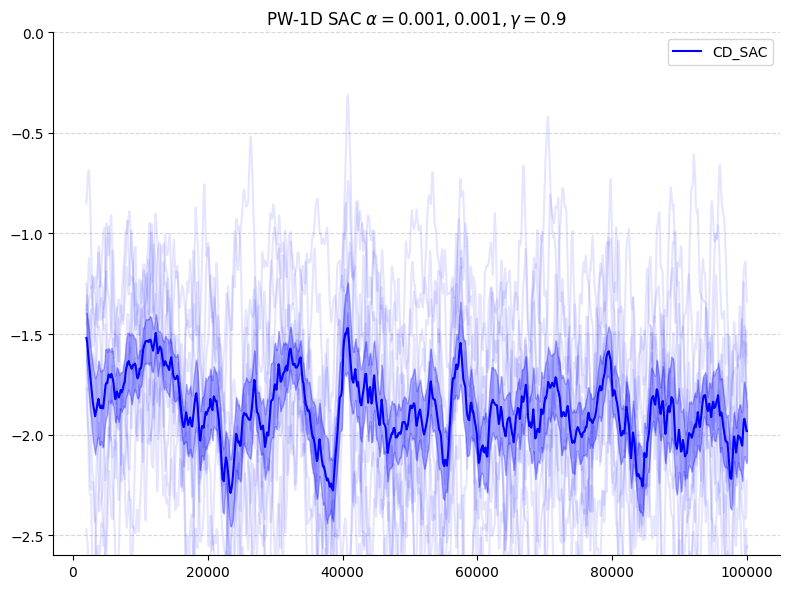

In [9]:
# step size: 0.001, 0.001, 100k, 128/128, 10 runs

filenames = [('../results/test_exp/', 'puckworld1D_cont_DiscSAC_0.npy'),]

plot_learning_curve(filenames, item='reward', window=2000, ylims=(-2.6, 0),
                    title=r'PW-1D SAC $\alpha=0.001, 0.001, \gamma=0.9$', final=False, plot_all_runs=True,
                   )

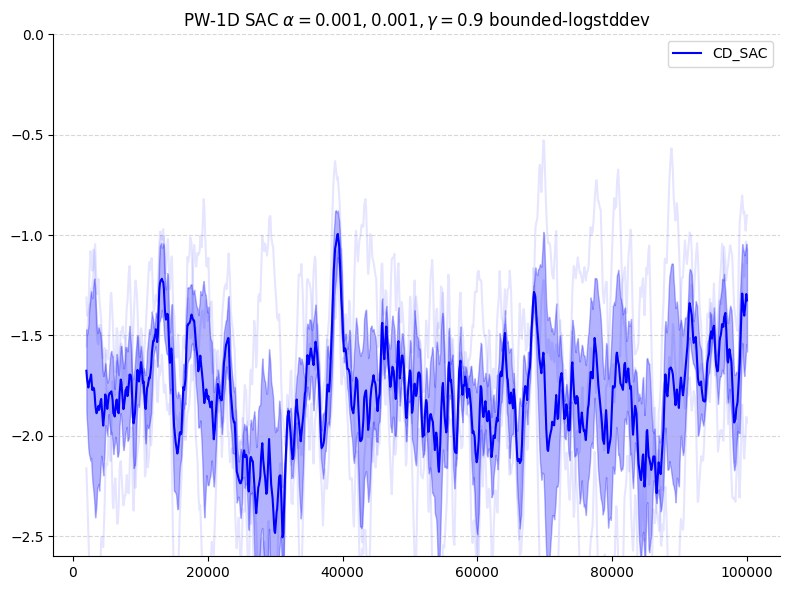

In [11]:
# step size: 0.001, 0.001, 100k, 128/128, 10 runs

filenames = [('../results/test_exp/', 'puckworld1D_cont_DiscSAC_logstddev_bounds_0.npy'),]

plot_learning_curve(filenames, item='reward', window=2000, ylims=(-2.6, 0),
                    title=r'PW-1D SAC $\alpha=0.001, 0.001, \gamma=0.9$ bounded-logstddev', final=False, plot_all_runs=True,
                   )

Observation mean and std: [ 4.333 -0.     2.46 ], [0.534 0.021 1.441]


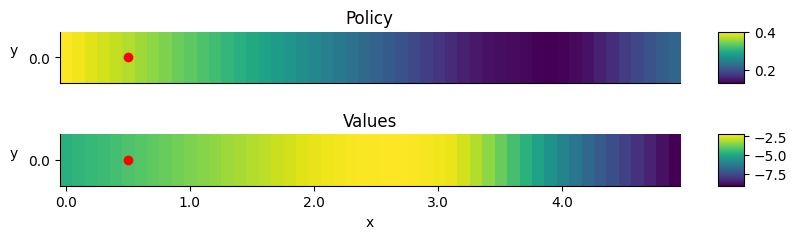

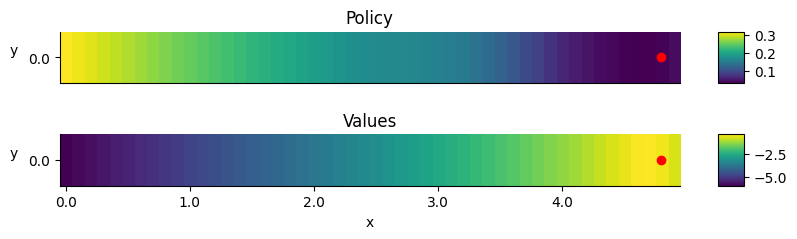

In [27]:
visualize_PW('../results/test_exp/', 'puckworld1D_cont_DiscSAC_logstddev_bounds_0.npy', goal_xs=[0.5, 4.8], critic_state_only=False, run_idx=2, norm_obs=True)

### PPO

Observation mean and std: [ 2.531 -0.     2.46 ], [1.427 0.069 1.441]


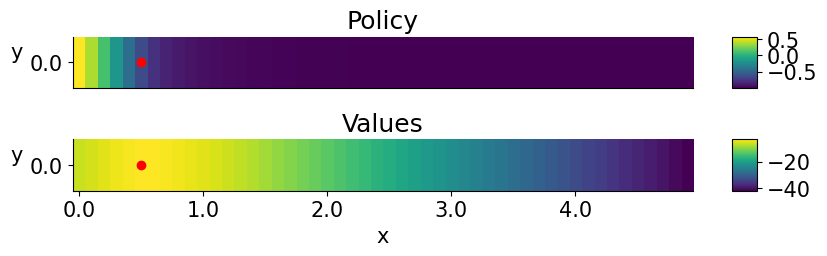

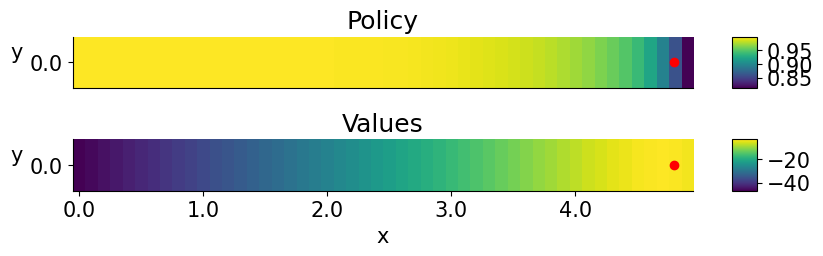

In [40]:
visualize_PW('results/test_exp/', 'puckworld1D_cont_CDiscPPO_batch64_0.001_0.001_epoch5_0.npy', goal_xs=[0.5, 4.8], critic_state_only=True, run_idx=2, norm_obs=True)

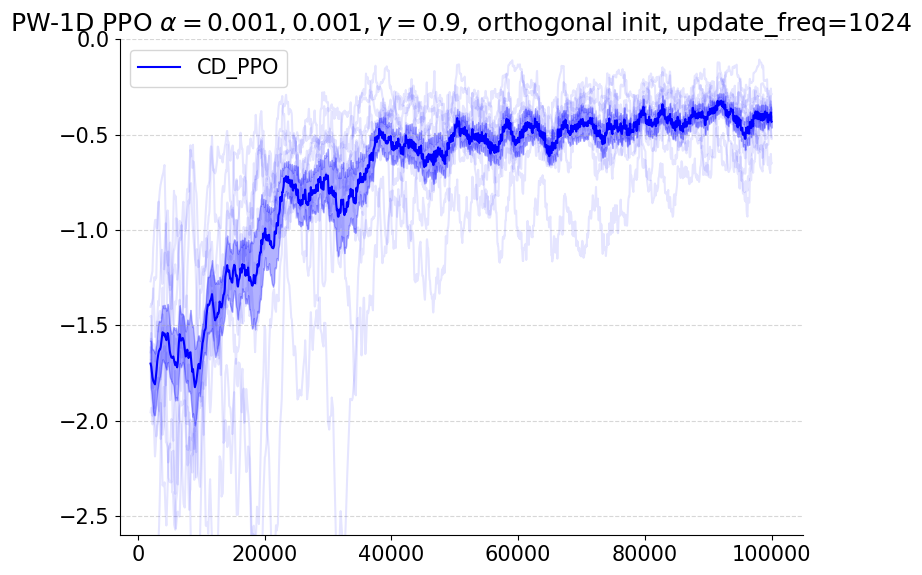

In [6]:
# step size: 0.001, 0.001, 100k, 128/64, sigma 1 -> 0.1, epoch5, 10 runs

filenames = [('results/test_exp/', 'puckworld1D_cont_CDiscPPO_batch64_0.001_0.001_epoch5_ortho_update1024_0.npy'),]

plot_learning_curve(filenames, item='reward', window=2000, ylims=(-2.6, 0),
                    title=r'PW-1D PPO $\alpha=0.001, 0.001, \gamma=0.9$, orthogonal init, update_freq=1024', final=False, plot_all_runs=True,
                   )

### DQN

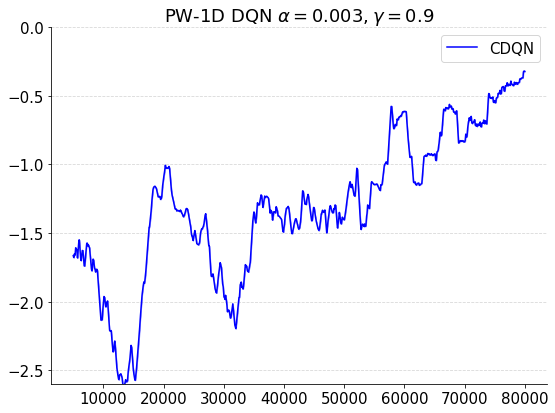

In [109]:
# step size: 0.003, 32x32

filenames = [
    ('results/test_exp/', 'puckworld1D_DQN_test_0.npy'),
]

plot_learning_curve(filenames, item='reward', window=5000, ylims=(-2.6, 0),
                    title=r'PW-1D DQN $\alpha=0.003, \gamma=0.9$', final=False, plot_all_runs=True,
                   )

### DDPG

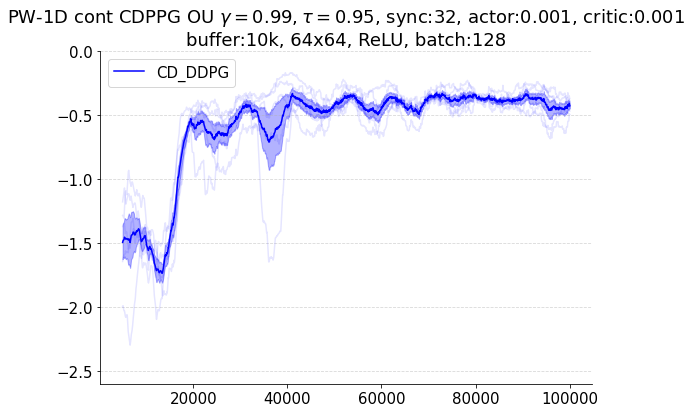

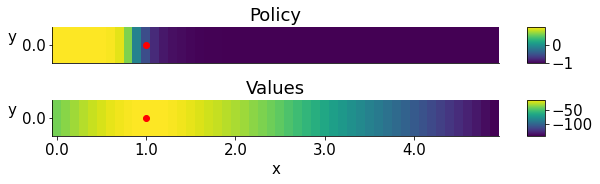

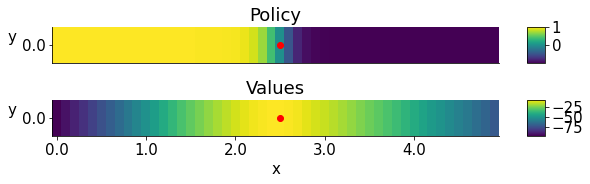

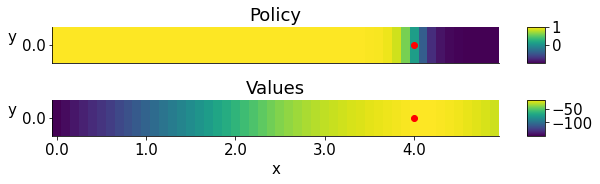

In [21]:
filenames = [('results/test_exp/', 'puckworld1D_cont_CDiscDDPG_0.npy'),]

plot_learning_curve(filenames, item='reward', window=5000, ylims=(-2.6, 0),
                    title=r'PW-1D cont CDPPG OU $\gamma=0.99, \tau=0.95$, sync:32, actor:0.001, critic:0.001' + '\n' + 'buffer:10k, 64x64, ReLU, batch:128', final=False, plot_all_runs=True,)
visualize_PW(filenames[0][0], filenames[0][1], goal_xs=[1, 2.5, 4], run_idx=0)

In [82]:
import copy

def debug_updates(results_folder, npy_log_file, seed=0):
    
    ### Creating the agent
    
    data = np.load(results_folder + npy_log_file, allow_pickle=True).item()
    agent_args = data['params']
    
    device = 'cpu'
    gamma = 0
    actor_arch = agent_args['actor_arch']
    num_actions = actor_arch[-1]
    torch.random.manual_seed(seed)
    
    actor = build_fc_net_tanh(actor_arch, final_activation_layer=torch.nn.Tanh()).to(device)
    actor_target = copy.deepcopy(actor).to(device)
#     load_model_from = agent_args.get('load_model_from', None)
#     if load_model_from:
#         actor.load_state_dict(torch.load(load_model_from))
#         print(f'Successfully loaded model from {load_model_from}')

    # initialize the critic network (and its target network)
    assert 'critic_arch' in agent_args, "critic_arch needs to be specified in agent_args"
    critic_arch = agent_args['critic_arch']
    assert critic_arch[0] == actor_arch[0] + actor_arch[-1], "the input of the critic network should be the concatenation of the state features and actions"
    assert critic_arch[-1] == 1, "the output of the critic network should be a single value"
    critic = build_fc_net_tanh(critic_arch).to(device)
    critic_target = copy.deepcopy(critic).to(device)
    tau = agent_args.get('tau', 0.995) # parameter for target networks' soft updates

    # initialize the loss functions and optimizers
    actor_optimizer_name = agent_args.get('actor_optimizer', 'None')
    actor_step_size = 0.01
    actor_optimizer = torch.optim.SGD(params=actor.parameters(), lr=actor_step_size)
    critic_loss_fn = torch.nn.MSELoss()
    critic_optimizer_name = agent_args.get('critic_optimizer', 'None')
    critic_step_size = 0.1
    critic_optimizer = torch.optim.SGD(params=critic.parameters(), lr=critic_step_size)
    
    ### Creating transitions
    
    states = torch.tensor([[2, 0, 4]], dtype=torch.float32)
    states = states.repeat(10,1)
    actions = torch.tensor([[0.5]], dtype=torch.float32)
    actions = actions.repeat(10,1)
    rewards = torch.tensor([[5]], dtype=torch.float32)
    rewards = rewards.repeat(10,1)
    next_states = torch.tensor([[3, 0, 4]], dtype=torch.float32)
    next_states = next_states.repeat(10,1)
    
    more_states = torch.tensor([[2, 0, 4]], dtype=torch.float32)
    more_states = more_states.repeat(10,1)
    more_actions = torch.tensor([[-0.5]], dtype=torch.float32)
    more_actions = more_actions.repeat(10,1)
    more_rewards = torch.tensor([[-5]], dtype=torch.float32)
    more_rewards = more_rewards.repeat(10,1)
    more_next_states = torch.tensor([[1, 0, 4]], dtype=torch.float32)
    more_next_states = more_next_states.repeat(10,1)
    
    states = torch.cat((states, more_states), 0)
    actions = torch.cat((actions, more_actions), 0)
    rewards = torch.cat((rewards, more_rewards), 0)
    next_states = torch.cat((next_states, more_next_states), 0)
    
    ### Computing values before updates
    
#     with torch.no_grad():
#         values_before = critic(torch.cat([states, actions], dim=1))
    
    xs = np.arange(0, 5, 0.1)
    ys = np.arange(0, 1, 1)

    test_states = np.zeros((xs.shape[0] * ys.shape[0], 3), dtype=np.float32)
    for i in range(xs.shape[0]):
        for j in range(ys.shape[0]):
            test_states[i*ys.shape[0] + j] = np.array([xs[i], 0, 4], dtype=np.float32) 
    
    with torch.no_grad():
        test_states = torch.from_numpy(test_states)
#         test_actions = actor(test_states)
        test_actions = torch.tensor([[0.5]], dtype=torch.float32).repeat(test_states.shape[0], 1)
        values = critic(torch.cat([test_states, test_actions], dim=1))
    
    fig, ax = plt.subplots(1,1)#, figsize=(10,10))
    plt.imshow(values.reshape((50, 1)).t(), aspect='auto')#, vmin=0.35, vmax=0.9)
    ax.set_xticks(np.arange(50)[::10], [f'{p:.1f}' for p in xs[::10]])
    ax.set_yticks(np.arange(1), [f'{v:.1f}' for v in ys])
    ax.set_xlabel('x')
    ax.set_ylabel('y', rotation=0, labelpad=10)
    plt.colorbar()
    plt.title('Before update')
    plt.show()
    
    ### Making updates
    
    q_current = critic(torch.cat([states, actions], dim=1))
    with torch.no_grad():
        next_actions = actor_target(next_states)
        q_next = critic_target(torch.cat([next_states, next_actions], dim=1))
        target_return = rewards + gamma * q_next

    # update the q_net parameters
    critic_loss = critic_loss_fn(q_current, target_return)
    critic_optimizer.zero_grad()
    critic_loss.backward()
    critic_optimizer.step()

    ### now, update the actor network
#     actions = actor(states)
#     actor_loss = -critic(torch.cat([states, actions], dim=1)).mean()
#     actor_optimizer.zero_grad()
#     actor_loss.backward()
#     actor_optimizer.step()
    
    ### Computing values after updates
#     with torch.no_grad():
#         values_after = critic(torch.cat([states, actions], dim=1))
        
    with torch.no_grad():
#         test_actions = actor(test_states)
        values = critic(torch.cat([test_states, test_actions], dim=1))
    
    fig, ax = plt.subplots(1,1)#, figsize=(10,10))
    plt.imshow(values.reshape((50, 1)).t(), aspect='auto')#, vmin=0.35, vmax=0.9)
    ax.set_xticks(np.arange(50)[::10], [f'{p:.1f}' for p in xs[::10]])
    ax.set_yticks(np.arange(1), [f'{v:.1f}' for v in ys])
    ax.set_xlabel('x')
    ax.set_ylabel('y', rotation=0, labelpad=10)
    plt.colorbar()
    plt.title('After update')
    plt.show()
    
#     print(f"Before update: {values_before}")
#     print(f"After update: {values_after}")

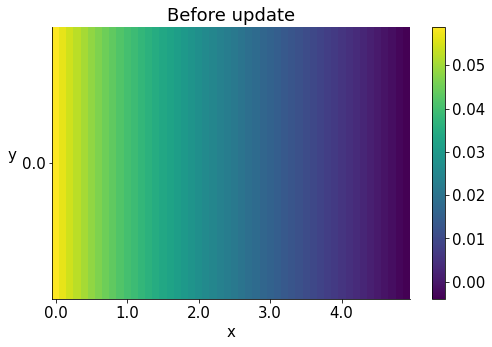

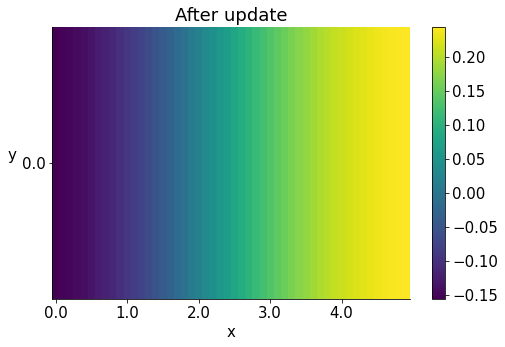

In [95]:
debug_updates('results/test_exp/', 'puckworld1D_cont_CDiscDDPG_test_32_50k_1-0.1_0.npy', seed=20)

In [85]:
a = torch.tensor([[1,2,3]])
print(a.repeat(3, 1))
print(a)

tensor([[1, 2, 3],
        [1, 2, 3],
        [1, 2, 3]])
tensor([[1, 2, 3]])


## Pendulum

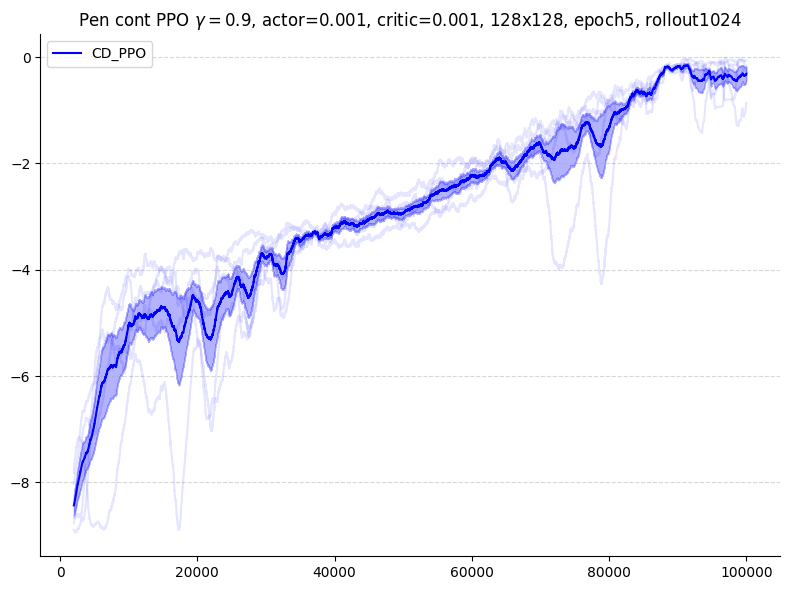

Observation mean and std: [-0.429  0.002 -0.114], [0.705 0.565 2.922]


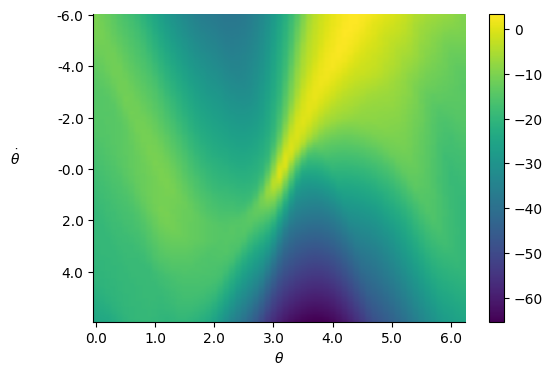

In [61]:
filenames = [('results/test_exp/', 'pendulum_cont_CDiscPPO_batch64_0.001_0.001_epoch5_0.npy'),]
plot_learning_curve(filenames, item='reward', window=2000, 
                    title=r'Pen cont PPO $\gamma=0.9$, actor=0.001, critic=0.001, 128x128, epoch5, rollout1024', final=False, plot_all_runs=True)#, ylims=(-10,0.5))
visualize_value_fn_pen(filenames[0][0], filenames[0][1], run_idx=0, critic_state_only=True, norm_obs=True)

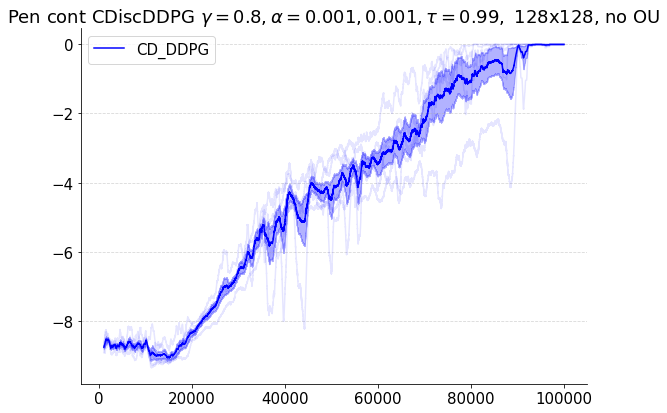

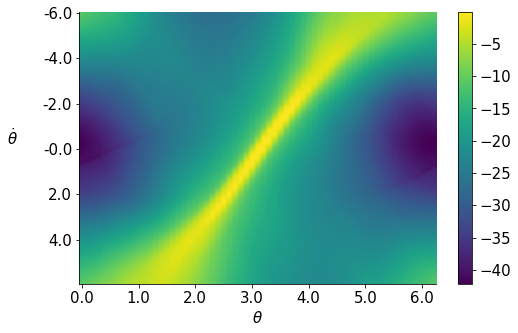

In [79]:
filenames = [('results/test_exp/', 'pendulum_cont_CDiscDDPG_gamma0.8_128x128_noOU_ss0.001_0.001_100k_tau0.99_0.npy'),]
plot_learning_curve(filenames, item='reward', window=1000, 
                    title=r'Pen cont CDiscDDPG $\gamma=0.8, \alpha=0.001, 0.001, \tau=0.99,$ 128x128, no OU', final=False, plot_all_runs=True)#, ylims=(-10,0.5))
visualize_value_fn_pen(filenames[0][0], filenames[0][1], run_idx=4)

## MountainCarContinuous

## gamma=0.9

Filename	avg_reward_init	alpha	Value

b0.5_3.	0	0.08	0.329	0.003
b0.5_2.	0	0.04	0.319	0.003
b0.5_0.	0	0.01	0.723	0.007
b0.5_1.	0	0.02	0.420	0.005
b0.5_4.	0	0.16	0.420	0.003
0.5_14.	0.25	0.16	0.397	0.003
0.5_11.	0.25	0.02	0.177	0.003
0.5_10.	0.25	0.01	0.200	0.004
0.5_12.	0.25	0.04	0.206	0.002
0.5_13.	0.25	0.08	0.278	0.003
0 0
1 0.25


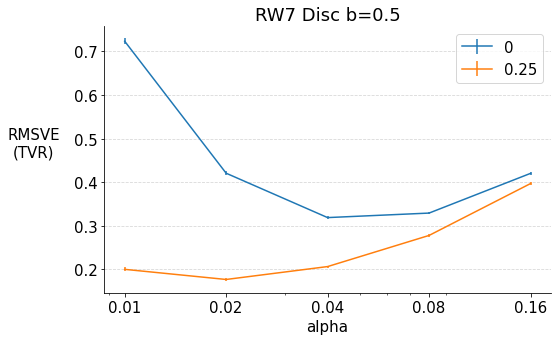

In [8]:
param_list = [('./results/centering/', 'RW7_DiscTD_b0.5', 'avg_reward_init'),]

plot_sensitivity(param_list, 'rmsve', ylabel='RMSVE\n(TVR)', param_choose_only=("gamma", 0.9),
                 logbase=10,
#                  y_lims=(0.5, 3), #firstn=400,
                 title=r'RW7 Disc b=0.5 $\gamma=0.9$', final=False)

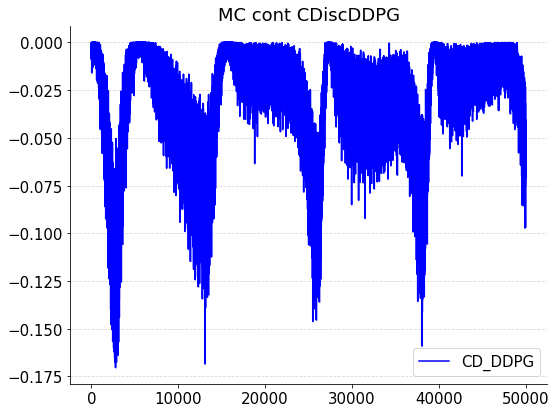

In [16]:
# fixed exploration sigma of 0.1

filenames = [
    ('results/test_exp/', 'MC_cont_CDiscDDPG_test_0.npy'),  # gamma=0.9, alpha=0.003,
]

plot_learning_curve(filenames, item='reward', window=1,
                    title=r'MC cont CDiscDDPG', final=False, plot_all_runs=True,
#                     print_final_reward_rate=True, #ylims=(0, 4),
                   )

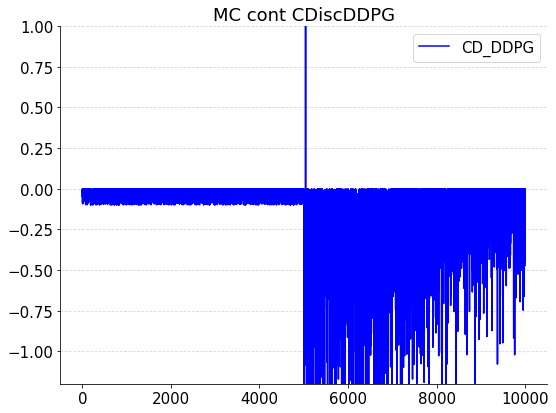

In [20]:
# initial random exploration for 10k steps, then fixed 0.1 sigma

filenames = [
    ('results/test_exp/', 'MC_cont_CDiscDDPG_test_0.npy'),  # gamma=0.9, alpha=0.003,
]

plot_learning_curve(filenames, item='reward', window=1,
                    title=r'MC cont CDiscDDPG', final=False, plot_all_runs=True,
                    ylims=(-1.2, 1), firstn=10000
                   )

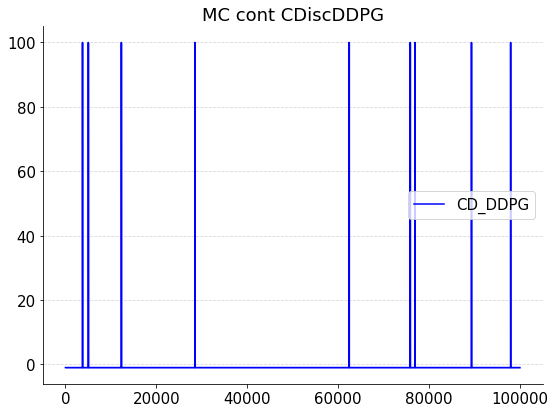

In [21]:
# new domain with -1 reward per step; exploration: linearly decaying sigma from 1 to 0.1

filenames = [
    ('results/test_exp/', 'MC_cont_CDiscDDPG_test_0.npy'),  # gamma=0.9, alpha=0.003,
]

plot_learning_curve(filenames, item='reward', window=1,
                    title=r'MC cont CDiscDDPG', final=False, plot_all_runs=True,
#                     print_final_reward_rate=True, #ylims=(0, 4),
                   )

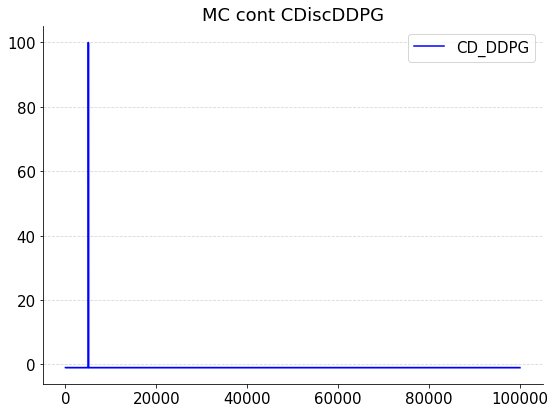

In [22]:
# new domain with -1 reward per step; exploration: linearly decaying sigma from 1 to 0.1
# step sizes: 0.01 and 0.03

filenames = [
    ('results/test_exp/', 'MC_cont_CDiscDDPG_test_0.npy'),  # gamma=0.9, alpha=0.003,
]

plot_learning_curve(filenames, item='reward', window=1,
                    title=r'MC cont CDiscDDPG', final=False, plot_all_runs=True,
                   )

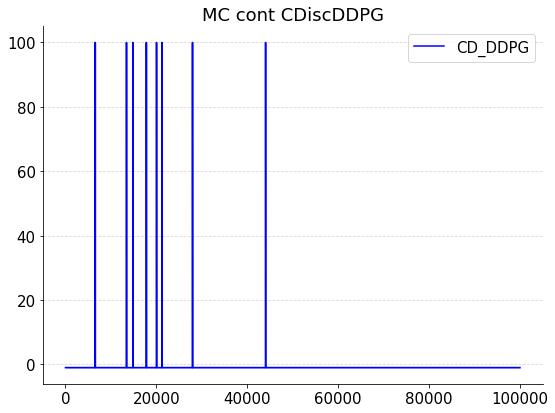

In [23]:
# new domain with -1 reward per step; exploration: linearly decaying sigma from 1 to 0.1
# step sizes: 0.001 and 0.003

filenames = [
    ('results/test_exp/', 'MC_cont_CDiscDDPG_test_0.npy'),  # gamma=0.9, alpha=0.003,
]

plot_learning_curve(filenames, item='reward', window=1,
                    title=r'MC cont CDiscDDPG', final=False, plot_all_runs=True,
                   )

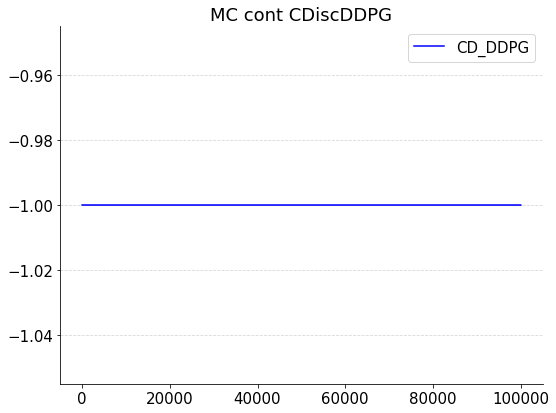

In [26]:
# new domain with -1 reward per step; exploration: linearly decaying sigma from 1 to 0.1
# step sizes: 0.001 and 0.003, 64 units each now

filenames = [
    ('results/test_exp/', 'MC_cont_CDiscDDPG_test_0.npy'),  # gamma=0.9, alpha=0.003,
]

plot_learning_curve(filenames, item='reward', window=1,
                    title=r'MC cont CDiscDDPG', final=False, plot_all_runs=True,
                   )

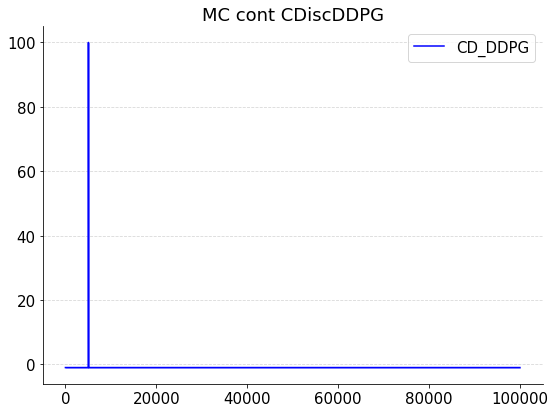

NameError: name 'filename' is not defined

In [179]:
# new domain with -1 reward per step; exploration: linearly decaying sigma from 1 to 0.1
# step sizes: 0.001 and 0.003, 64 units each
# inputs centered in [-1, 1]

filenames = [
    ('results/test_exp/', 'MC_cont_CDiscDDPG_test_0.npy'),  # gamma=0.9, alpha=0.003,
]

plot_learning_curve(filenames, item='reward', window=1,
                    title=r'MC cont CDiscDDPG', final=False, plot_all_runs=True,
                   )

visualize_value_fn_MC(filenames[0], filenames[1])

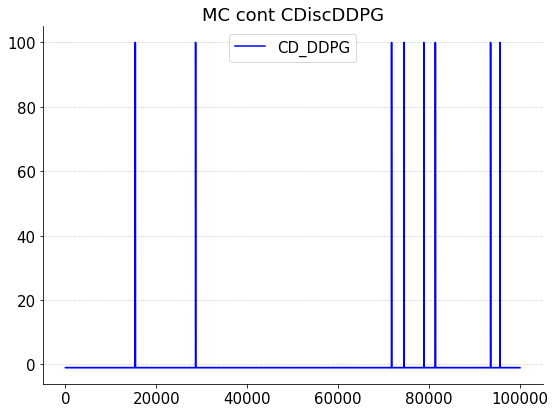

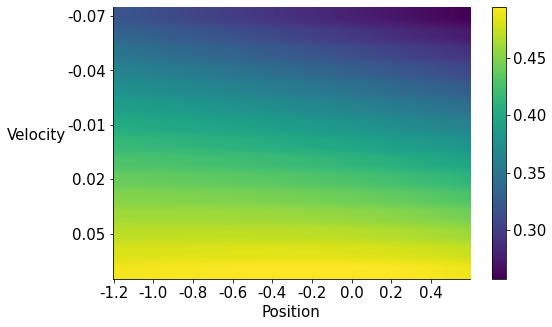

In [182]:
# new domain with -1 reward per step; exploration: 1.3 constant
# step sizes: 0.0001 and 0.0003, 4 units each
# inputs centered in [-1, 1]

filenames = [
    ('results/test_exp/', 'MC_cont_CDiscDDPG_test_0.npy'),  # gamma=0.9, alpha=0.003,
]

plot_learning_curve(filenames, item='reward', window=1,
                    title=r'MC cont CDiscDDPG', final=False, plot_all_runs=True,
                   )

visualize_value_fn_MC(filenames[0][0], filenames[0][1])

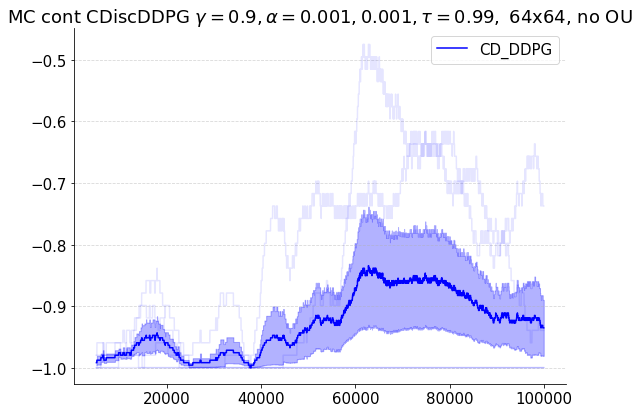

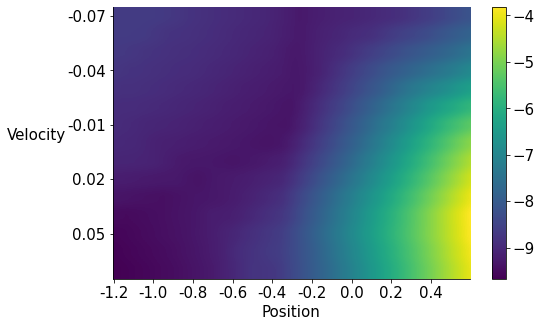

In [85]:
filenames = [('results/test_exp/', 'MCC_cont_CDiscDDPG_gamma0.9_64x64_noOU_ss0.001_0.001_100k_tau0.99_0.npy'),]

plot_learning_curve(filenames, item='reward', window=5000, final=False, plot_all_runs=True,
                    title=r'MC cont CDiscDDPG $\gamma=0.9, \alpha=0.001, 0.001, \tau=0.99,$ 64x64, no OU',)
visualize_value_fn_MC(filenames[0][0], filenames[0][1])

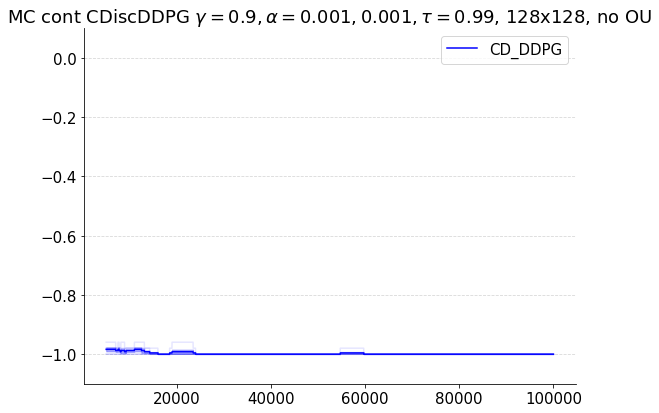

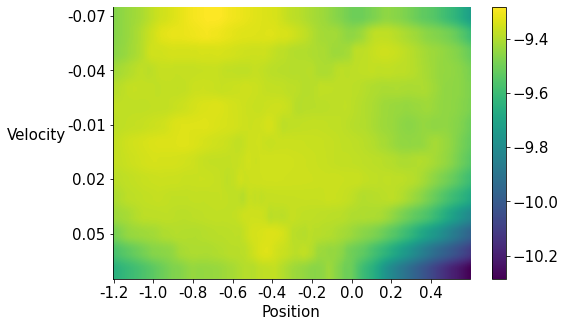

In [87]:
filenames = [('results/test_exp/', 'MCC_cont_CDiscDDPG_gamma0.9_128x128_noOU_ss0.001_0.001_100k_tau0.99_0.npy'),]

plot_learning_curve(filenames, item='reward', window=5000, final=False, plot_all_runs=True, ylims=(-1.1, 0.1),
                    title=r'MC cont CDiscDDPG $\gamma=0.9, \alpha=0.001, 0.001, \tau=0.99$, 128x128, no OU',)
visualize_value_fn_MC(filenames[0][0], filenames[0][1])

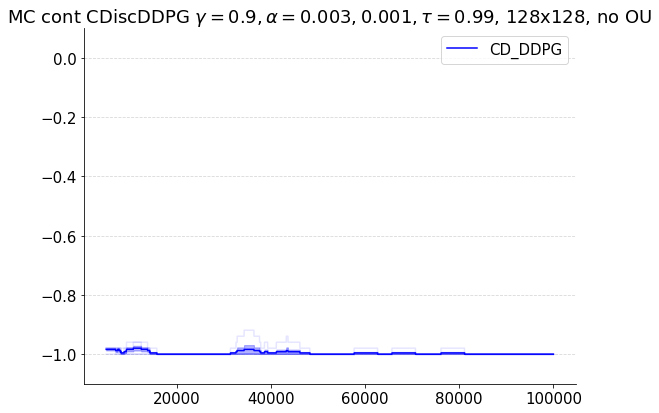

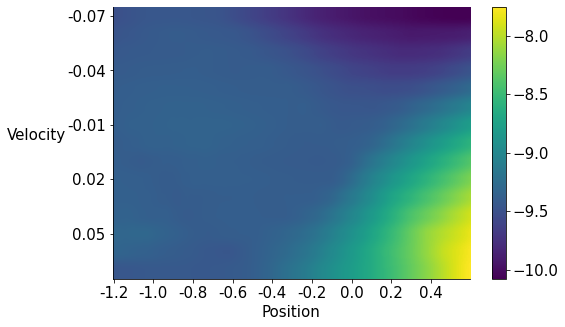

In [90]:
filenames = [('results/test_exp/', 'MCC_cont_CDiscDDPG_gamma0.9_64x64_noOU_ss0.003_0.001_100k_tau0.99_0.npy'),]

plot_learning_curve(filenames, item='reward', window=5000, final=False, plot_all_runs=True, ylims=(-1.1, 0.1),
                    title=r'MC cont CDiscDDPG $\gamma=0.9, \alpha=0.003, 0.001, \tau=0.99$, 128x128, no OU',)
visualize_value_fn_MC(filenames[0][0], filenames[0][1], run_idx=2)